In [1]:
import torch 

import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train = pd.read_csv('fashion-mnist_train.csv')
test = pd.read_csv('fashion-mnist_test.csv')

X_train = train.drop('label', axis=1)
y_train = train['label']
X_train = (X_train/255.0 - 0.5)/0.5
X_train = X_train.values
y_train = y_train.values

X_test = test.drop('label', axis=1)
y_test = test['label']
X_test = (X_test/255.0 -0.5 ) /0.5
X_test = X_test.values
y_test = y_test.values




In [2]:
class CustomDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(X,dtype=torch.float32).view(-1,1,28,28)
        self.y = torch.tensor(y,dtype=torch.long)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self,index):
        return self.X[index] , self.y[index]
    
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle=True,pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, pin_memory=torch.cuda.is_available())


In [3]:
class fashion_cnn(nn.Module):
    def __init__(self, n_labels =10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1,32,3,1),
            nn.ReLU(),


            nn.Conv2d(32,64,3,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Flatten(),

            nn.Linear(128*5*5,1000),
            nn.ReLU(),
            nn.Linear(1000,250),
            nn.ReLU(),
            nn.Linear(250,100),
            nn.ReLU(),
            nn.Linear(100,10)

        )
    def forward(self,X):
        return self.model(X)
    
model = fashion_cnn(10)
model = model.to(device)

model

fashion_cnn(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=3200, out_features=1000, bias=True)
    (10): ReLU()
    (11): Linear(in_features=1000, out_features=250, bias=True)
    (12): ReLU()
    (13): Linear(in_features=250, out_features=100, bias=True)
    (14): ReLU()
    (15): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [4]:
loss_fn = nn.CrossEntropyLoss()
epochs =5
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

Epoch : [1 / 5] : 0.6886948086
Epoch : [2 / 5] : 0.4381112069
Epoch : [3 / 5] : 0.3692163574
Epoch : [4 / 5] : 0.3252325429
Epoch : [5 / 5] : 0.2925976128


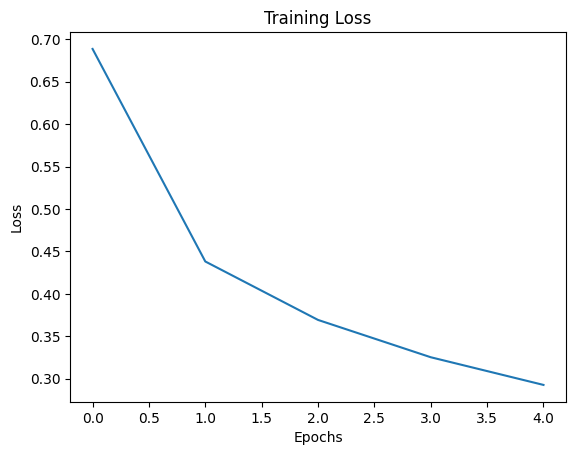

In [5]:
train_loss = []
for epoch in range(epochs):
    model.train()
    total_epoch_loss = 0
    
    for batch_X,batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        y_pred = model(batch_X)
        loss = loss_fn(y_pred,batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss+= loss.item()
    

    average_epoch_loss = total_epoch_loss/len(train_loader)
    train_loss.append(average_epoch_loss)
    print(f"Epoch : [{epoch + 1 } / {epochs}] : {average_epoch_loss:.10f}")
plt.plot([t1 for t1 in train_loss])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [7]:
total_labels = len(test_dataset)
correct = 0
model.eval()

with torch.no_grad():
    for batch_X,batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        y_preds = model(batch_X)
        predicted_labl = torch.argmax(y_preds,dim =1)

        batch_correct_preds = (predicted_labl == batch_y).sum().item()
        correct += batch_correct_preds
print(correct)
acc = correct/ total_labels
print(f"The accuracy of the currrent model is : {acc*100:.10f}")

8967
The accuracy of the currrent model is : 89.6700000000
